# Dodawanie i mnożenie

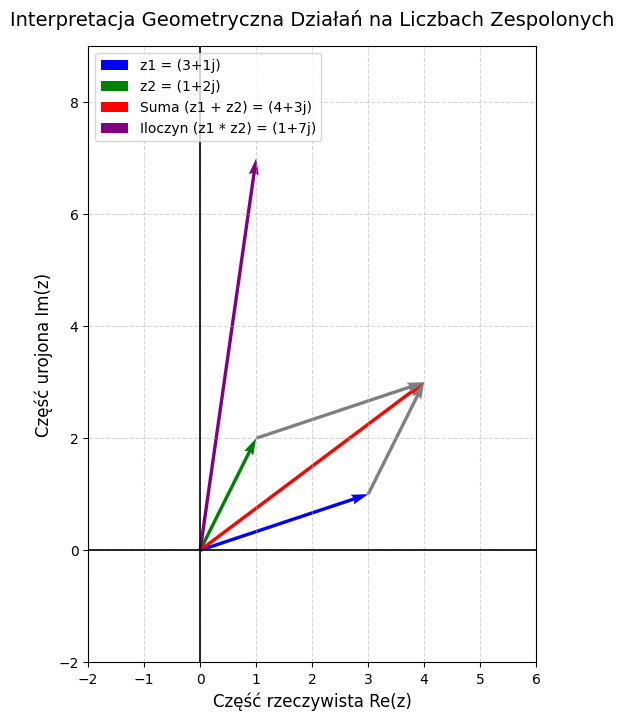

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def rysuj_liczby_zespolone(z1: complex, z2: complex):
    # Wykonujemy działania w pamięci Pythona
    z_suma = z1 + z2
    z_iloczyn = z1 * z2

    fig, ax = plt.subplots(figsize=(10, 8))

    # Pomocnicza funkcja do rysowania wektorów
    def dodaj_wektor(z, kolor, etykieta, podstawa=(0, 0), ls='-'):
        ax.quiver(podstawa[0], podstawa[1], z.real, z.imag, 
                  angles='xy', scale_units='xy', scale=1, 
                  color=kolor, label=etykieta, linestyle=ls)

    # 1. Rysowanie wektorów bazowych
    dodaj_wektor(z1, 'blue', f'z1 = {z1}')
    dodaj_wektor(z2, 'green', f'z2 = {z2}')

    # 2. Wizualizacja dodawania (metoda równoległoboku)
    # Rysujemy z_suma od punktu (0,0)
    dodaj_wektor(z_suma, 'red', f'Suma (z1 + z2) = {z_suma}')
    # Rysujemy boki pomocnicze równoległoboku
    dodaj_wektor(z2, 'gray', '_nolegend_', podstawa=(z1.real, z1.imag), ls=':')
    dodaj_wektor(z1, 'gray', '_nolegend_', podstawa=(z2.real, z2.imag), ls=':')

    # 3. Wizualizacja mnożenia
    dodaj_wektor(z_iloczyn, 'purple', f'Iloczyn (z1 * z2) = {z_iloczyn}')

    # Dynamiczne dopasowanie limitów osi wykresu
    wszystkie_x = [0, z1.real, z2.real, z_suma.real, z_iloczyn.real]
    wszystkie_y = [0, z1.imag, z2.imag, z_suma.imag, z_iloczyn.imag]
    margin = 2
    ax.set_xlim(min(wszystkie_x) - margin, max(wszystkie_x) + margin)
    ax.set_ylim(min(wszystkie_y) - margin, max(wszystkie_y) + margin)

    # Konfiguracja osi i siatki (Płaszczyzna Gaussa)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.axvline(0, color='black', linewidth=1.2)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.set_aspect('equal') # Zachowanie proporcji 1:1 dla poprawnych kątów
    
    ax.set_xlabel('Część rzeczywista Re(z)', fontsize=12)
    ax.set_ylabel('Część urojona Im(z)', fontsize=12)
    ax.set_title('Interpretacja Geometryczna Działań na Liczbach Zespolonych', fontsize=14, pad=15)
    ax.legend(loc='upper left')

    plt.show()

# --- PRZYKŁAD UŻYCIA ---
# Definiujemy dwie liczby zespolone (używając litery 'j' dla części urojonej)
z1 = 3 + 1j
z2 = 1 + 2j

rysuj_liczby_zespolone(z1, z2)

## Potęgowanie i pierwiastkowanie liczb zespolonych

Liczbę zespoloną niezerową zapisujemy w postaci trygonometrycznej:

$$
z = r(\cos\theta + i\sin\theta), \qquad r=|z|,\quad \theta=\arg(z).
$$

### Potęgowanie

Ze wzoru de Moivre’a:

$$
z^n = r^n(\cos(n\theta)+i\sin(n\theta)).
$$

Przy potęgowaniu moduł podnosi się do potęgi $n$, a argument mnoży przez $n$. Geometrycznie kolejne potęgi $1,z,z^2,\ldots,z^n$ mają moduły $1,r,r^2,\ldots,r^n$ i argumenty $0,\theta,2\theta,\ldots,n\theta$. To powtarzane mnożenie przez $z$: za każdym razem wektor obraca się o $\theta$ i zmienia długość $r$ razy.

### Pierwiastkowanie

Pierwiastki $n$-tego stopnia z $z$ to rozwiązania równania $w^n=z$. Dla $z\ne 0$ jest ich dokładnie $n$:

$$
w_k = \sqrt[n]{r}\left(\cos\frac{\theta+2\pi k}{n}+i\sin\frac{\theta+2\pi k}{n}\right),
\qquad k=0,1,\ldots,n-1.
$$

Wszystkie pierwiastki leżą na okręgu o promieniu $\sqrt[n]{r}$, a ich argumenty różnią się o $2\pi/n$. Są więc rozmieszczone równomiernie. Dla $z=0$ jedynym różnym pierwiastkiem jest $0$ (wzór zwraca go $n$ razy). W komórce poniżej zmień $z$ oraz $n$, aby obejrzeć inne przykłady.

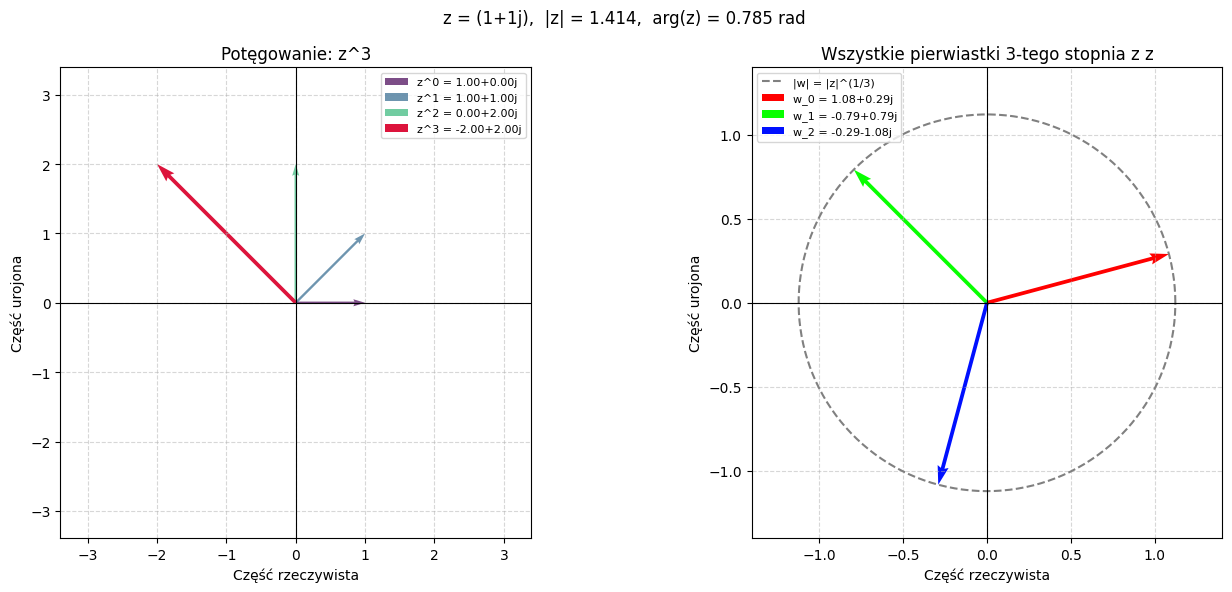

z^3 = (-2+2j)
Pierwiastki 3-tego stopnia:
w_0 = (1.0842150814913512+0.2905145555072514j)
w_1 = (-0.7937005259840997+0.7937005259840998j)
w_2 = (-0.2905145555072513-1.0842150814913512j)


In [12]:
import matplotlib.pyplot as plt
import numpy as np


def pierwiastki_ntego_stopnia(z: complex, n: int) -> list[complex]:
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n musi być dodatnią liczbą całkowitą")

    if z == 0:
        return [0j] * n

    modul = abs(z)
    argument = np.angle(z)
    promien = modul ** (1 / n)
    return [
        promien * np.exp(1j * (argument + 2 * np.pi * k) / n)
        for k in range(n)
    ]


def rysuj_potegowanie_i_pierwiastkowanie(z: complex, n: int):
    if not isinstance(n, int) or isinstance(n, bool) or n < 1:
        raise ValueError("n musi być dodatnią liczbą całkowitą")

    potegi = [z ** k for k in range(n + 1)]
    pierwiastki = pierwiastki_ntego_stopnia(z, n)

    fig, (ax_potegi, ax_pierwiastki) = plt.subplots(1, 2, figsize=(14, 6))

    # Kolejne potęgi mają argumenty k razy większe, a moduły podnoszone do k.
    for k, potega in enumerate(potegi):
        kolor = 'crimson' if k == n else plt.cm.viridis(k / max(n, 1))
        ax_potegi.quiver(
            0, 0, potega.real, potega.imag,
            angles='xy', scale_units='xy', scale=1,
            color=kolor, alpha=1 if k == n else 0.7,
            width=0.008 if k == n else 0.005,
            label=f'z^{k} = {potega:.2f}',
        )

    zasieg_poteg = max(1.0, *(abs(potega) for potega in potegi)) * 1.2
    ax_potegi.set_xlim(-zasieg_poteg, zasieg_poteg)
    ax_potegi.set_ylim(-zasieg_poteg, zasieg_poteg)
    ax_potegi.set_title(f'Potęgowanie: z^{n}')
    ax_potegi.set_xlabel('Część rzeczywista')
    ax_potegi.set_ylabel('Część urojona')
    ax_potegi.legend(loc='best', fontsize=8)
    ax_potegi.grid(True, linestyle='--', alpha=0.5)

    # Pierwiastki leżą równomiernie na okręgu o promieniu |z|^(1/n).
    promien = abs(z) ** (1 / n)
    katy_okregu = np.linspace(0, 2 * np.pi, 300)
    ax_pierwiastki.plot(
        promien * np.cos(katy_okregu),
        promien * np.sin(katy_okregu),
        color='gray', linestyle='--', label=f'|w| = |z|^(1/{n})',
    )

    for k, pierwiastek in enumerate(pierwiastki):
        ax_pierwiastki.quiver(
            0, 0, pierwiastek.real, pierwiastek.imag,
            angles='xy', scale_units='xy', scale=1,
            color=plt.cm.hsv(k / n), width=0.008,
            label=f'w_{k} = {pierwiastek:.2f}',
        )

    zasieg_pierwiastkow = max(1.0, promien) * 1.25
    ax_pierwiastki.set_xlim(-zasieg_pierwiastkow, zasieg_pierwiastkow)
    ax_pierwiastki.set_ylim(-zasieg_pierwiastkow, zasieg_pierwiastkow)
    ax_pierwiastki.set_title(f'Wszystkie pierwiastki {n}-tego stopnia z z')
    ax_pierwiastki.set_xlabel('Część rzeczywista')
    ax_pierwiastki.set_ylabel('Część urojona')
    ax_pierwiastki.legend(loc='best', fontsize=8)
    ax_pierwiastki.grid(True, linestyle='--', alpha=0.5)

    for ax in (ax_potegi, ax_pierwiastki):
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_aspect('equal')

    fig.suptitle(
        f'z = {z},  |z| = {abs(z):.3f},  arg(z) = {np.angle(z):.3f} rad'
    )
    plt.tight_layout()
    plt.show()
    return potegi[-1], pierwiastki


# Przykład: zmień z i n, aby zobaczyć inne potęgi i pierwiastki.
z = 1 + 1j
n = 3
potega, pierwiastki = rysuj_potegowanie_i_pierwiastkowanie(z, n)
print(f'z^{n} = {potega}')
print(f'Pierwiastki {n}-tego stopnia:')
for k, pierwiastek in enumerate(pierwiastki):
    print(f'w_{k} = {pierwiastek}')

## Symboliczne obliczenia z liczbami zespolonymi w SymPy

Biblioteka `SymPy` pozwala wykonywać dokładne obliczenia algebraiczne. W odróżnieniu od zwykłych liczb Pythona, `I` oznacza jednostkę urojoną, a nie przybliżenie dziesiętne. SymPy potrafi rozwijać i upraszczać wyrażenia, wyznaczać części rzeczywiste i urojone oraz rozwiązywać równania.

Ważne: aby SymPy wiedział, że zmienne `x`, `y`, `u`, `v` są rzeczywiste, deklarujemy je z `real=True`. Dzięki temu poprawnie upraszcza m.in. moduł liczby `x + I*y`.

W kolejnej komórce:

- mnożymy dwie ogólne liczby zespolone i odczytujemy część rzeczywistą oraz urojoną;
- obliczamy moduł i sprzężenie zespolone;
- rozwijamy symboliczną trzecią potęgę;
- rozwiązujemy równanie `w**3 = 1 + I`, otrzymując wszystkie trzy pierwiastki, i sprawdzamy każde rozwiązanie przez podstawienie.

Wyniki pozostają dokładne. Metoda `.evalf()` służy dopiero do uzyskania
przybliżenia dziesiętnego.

`sp.latex` słuzy wyłącznie do wyrenderowania wyniku.

In [13]:
import sympy as sp
from IPython.display import Math, display

# I to jednostka urojona; symbole z real=True są zmiennymi rzeczywistymi.
I = sp.I
x, y, u, v = sp.symbols("x y u v", real=True)
z1 = x + I * y
z2 = u + I * v

# Mnożenie i rozdzielenie wyniku na część rzeczywistą i urojoną.
iloczyn = sp.expand(z1 * z2)
display(Math(r"z_1 z_2 = " + sp.latex(iloczyn)))
display(Math(r"\operatorname{Re}(z_1 z_2) = " + sp.latex(sp.re(iloczyn))))
display(Math(r"\operatorname{Im}(z_1 z_2) = " + sp.latex(sp.im(iloczyn))))

# Moduł i sprzężenie liczby zespolonej.
display(Math(r"|z_1| = " + sp.latex(sp.simplify(sp.Abs(z1)))))
display(Math(r"\overline{z_1} = " + sp.latex(sp.conjugate(z1))))

# Rozwinięcie potęgi dla ogólnego z = x + I*y.
display(Math(r"z_1^3 = " + sp.latex(sp.expand_complex(z1**3))))

# Rozwiązanie równania w^3 = 1 + I.
w = sp.symbols("w")
z_przyklad = 1 + I
pierwiastki_sym = sp.solve(w**3 - z_przyklad, w)
display(Math(r"\text{Rozwiązania równania } w^3 = 1+i:"))
for numer, pierwiastek in enumerate(pierwiastki_sym):
    display(Math(rf"w_{{{numer}}} = " + sp.latex(pierwiastek)))
    sprawdzenie = sp.simplify(pierwiastek**3 - z_przyklad)
    display(Math(rf"w_{{{numer}}}^3 - (1+i) = " + sp.latex(sprawdzenie)))

# Dokładne wyniki można zamienić na przybliżenia dziesiętne.
display(Math(r"\text{Przybliżenia dziesiętne:}"))
for numer, pierwiastek in enumerate(pierwiastki_sym):
    display(Math(rf"w_{{{numer}}} \approx " + sp.latex(sp.N(pierwiastek, 4))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>